# 🫀 Hybrid LSTM-RoBERTa untuk Klasifikasi Sinyal ECG

Notebook ini mengimplementasikan:
1. **LSTM Model** untuk klasifikasi sinyal ECG (Target: 59% accuracy)
2. **RoBERTa Model** untuk klasifikasi report German (Target: 89% accuracy) 
3. **Hybrid LSTM-RoBERTa** untuk fusion multi-modal

Dataset: PTB-XL dengan 499 ECG signals dan German medical reports

In [2]:
# Import libraries dan setup progress bar
import pandas as pd
import numpy as np
import os
import wfdb
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
import warnings
warnings.filterwarnings('ignore')

# Deep Learning
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input, Conv1D, MaxPooling1D, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# PyTorch untuk RoBERTa
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import XLMRobertaTokenizer, XLMRobertaModel

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler

print("✅ All libraries imported successfully!")
print(f"TensorFlow: {tf.__version__}")
print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

C:\Users\Leo\AppData\Roaming\Python\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ All libraries imported successfully!
TensorFlow: 2.18.0
PyTorch: 2.6.0+cpu
CUDA available: False


In [2]:
# Load PTB-XL Database
print("📊 Loading PTB-XL Database...")

# Paths
ptbxl_data_path = '../data/physionet.org/files/ptb-xl/1.0.3/'
ptbxl_db_path = '../data/physionet.org/files/ptb-xl/1.0.3/ptbxl_database.csv'

# Load database
df = pd.read_csv(ptbxl_db_path)
print(f"Total records: {len(df)}")
print(f"Columns: {list(df.columns)}")

# Filter untuk mendapatkan 499 samples seperti hasil sebelumnya
# Fokus pada data dengan report yang tidak kosong
df_filtered = df[df['report'].notna() & (df['report'] != '')].copy()
df_work = df_filtered.head(499).copy()  # 499 samples sesuai target

print(f"\n📋 Working dataset: {len(df_work)} samples")
print(f"Sample reports available: {df_work['report'].notna().sum()}")

# Check label distribution
# Parse SCP codes untuk binary classification
df_work['scp_codes_dict'] = df_work['scp_codes'].apply(lambda x: eval(x) if pd.notna(x) else {})
df_work['is_normal'] = df_work['scp_codes_dict'].apply(lambda x: 'NORM' in x)
df_work['binary_label'] = (~df_work['is_normal']).astype(int)  # 0=Normal, 1=Abnormal

label_counts = df_work['binary_label'].value_counts()
print(f"\n🏷️ Label distribution:")
print(f"Normal (0): {label_counts[0]} samples ({label_counts[0]/len(df_work)*100:.1f}%)")
print(f"Abnormal (1): {label_counts[1]} samples ({label_counts[1]/len(df_work)*100:.1f}%)")

# Show sample reports
print(f"\n📄 Sample German reports:")
for i in range(3):
    sample_report = df_work.iloc[i]['report']
    sample_label = df_work.iloc[i]['binary_label']
    label_text = 'Normal' if sample_label == 0 else 'Abnormal'
    print(f"{i+1}. [{label_text}] {sample_report[:100]}...")

📊 Loading PTB-XL Database...
Total records: 21799
Columns: ['ecg_id', 'patient_id', 'age', 'sex', 'height', 'weight', 'nurse', 'site', 'device', 'recording_date', 'report', 'scp_codes', 'heart_axis', 'infarction_stadium1', 'infarction_stadium2', 'validated_by', 'second_opinion', 'initial_autogenerated_report', 'validated_by_human', 'baseline_drift', 'static_noise', 'burst_noise', 'electrodes_problems', 'extra_beats', 'pacemaker', 'strat_fold', 'filename_lr', 'filename_hr']

📋 Working dataset: 499 samples
Sample reports available: 499

🏷️ Label distribution:
Normal (0): 297 samples (59.5%)
Abnormal (1): 202 samples (40.5%)

📄 Sample German reports:
1. [Normal] sinusrhythmus periphere niederspannung...
2. [Normal] sinusbradykardie sonst normales ekg...
3. [Normal] sinusrhythmus normales ekg...


In [3]:
# Load ECG Signals
print("🫀 Loading ECG signals...")

def load_ecg_signal(filename, data_path):
    """Load single ECG signal dari WFDB format"""
    try:
        full_path = os.path.join(data_path, filename)
        record = wfdb.rdrecord(full_path)
        signal = record.p_signal  # Shape: (time_steps, leads)
        
        # Resample to fixed length (2500 points = 10 seconds at 250Hz)
        target_length = 2500
        if signal.shape[0] != target_length:
            from scipy import signal as scipy_signal
            signal = scipy_signal.resample(signal, target_length)
        
        return signal
    except Exception as e:
        print(f"Error loading {filename}: {e}")
        return None

# Load ECG signals dengan progress bar
ecg_signals = []
labels = []
reports = []
valid_indices = []

print(f"Loading {len(df_work)} ECG signals...")
for idx, row in tqdm(df_work.iterrows(), total=len(df_work), desc="Loading ECG"):
    filename = row['filename_lr']  # Low resolution files
    signal = load_ecg_signal(filename, ptbxl_data_path)
    
    if signal is not None and signal.shape[1] == 12:  # 12-lead ECG
        ecg_signals.append(signal)
        labels.append(row['binary_label'])
        reports.append(row['report'])
        valid_indices.append(idx)

# Convert to numpy arrays
ecg_signals = np.array(ecg_signals)
labels = np.array(labels)

print(f"\n✅ Successfully loaded:")
print(f"ECG signals: {ecg_signals.shape} (samples, time_steps, leads)")
print(f"Labels: {len(labels)} samples")
print(f"Reports: {len(reports)} German texts")

# Final label distribution
final_label_counts = np.bincount(labels)
normal_count = final_label_counts[0]
abnormal_count = final_label_counts[1] if len(final_label_counts) > 1 else 0
print(f"\nFinal distribution: {normal_count} normal, {abnormal_count} abnormal")
print(f"Target: 297 normal, 202 abnormal ({'✓' if abs(normal_count-297) < 50 else '❌'})")

🫀 Loading ECG signals...
Loading 499 ECG signals...


Loading ECG:  97%|█████████▋| 483/499 [00:08<00:00, 59.65it/s]

Error loading records100/00000/00485_lr: [Errno 2] No such file or directory: 'c:/joki/klasifikasi-sinyal-elektrokardiogram/data/physionet.org/files/ptb-xl/1.0.3/records100/00000/00485_lr.dat'


Loading ECG: 100%|██████████| 499/499 [00:08<00:00, 57.68it/s]


✅ Successfully loaded:
ECG signals: (498, 2500, 12) (samples, time_steps, leads)
Labels: 498 samples
Reports: 498 German texts

Final distribution: 297 normal, 201 abnormal
Target: 297 normal, 202 abnormal (✓)


📈 Visualizing sample 12-lead ECG...


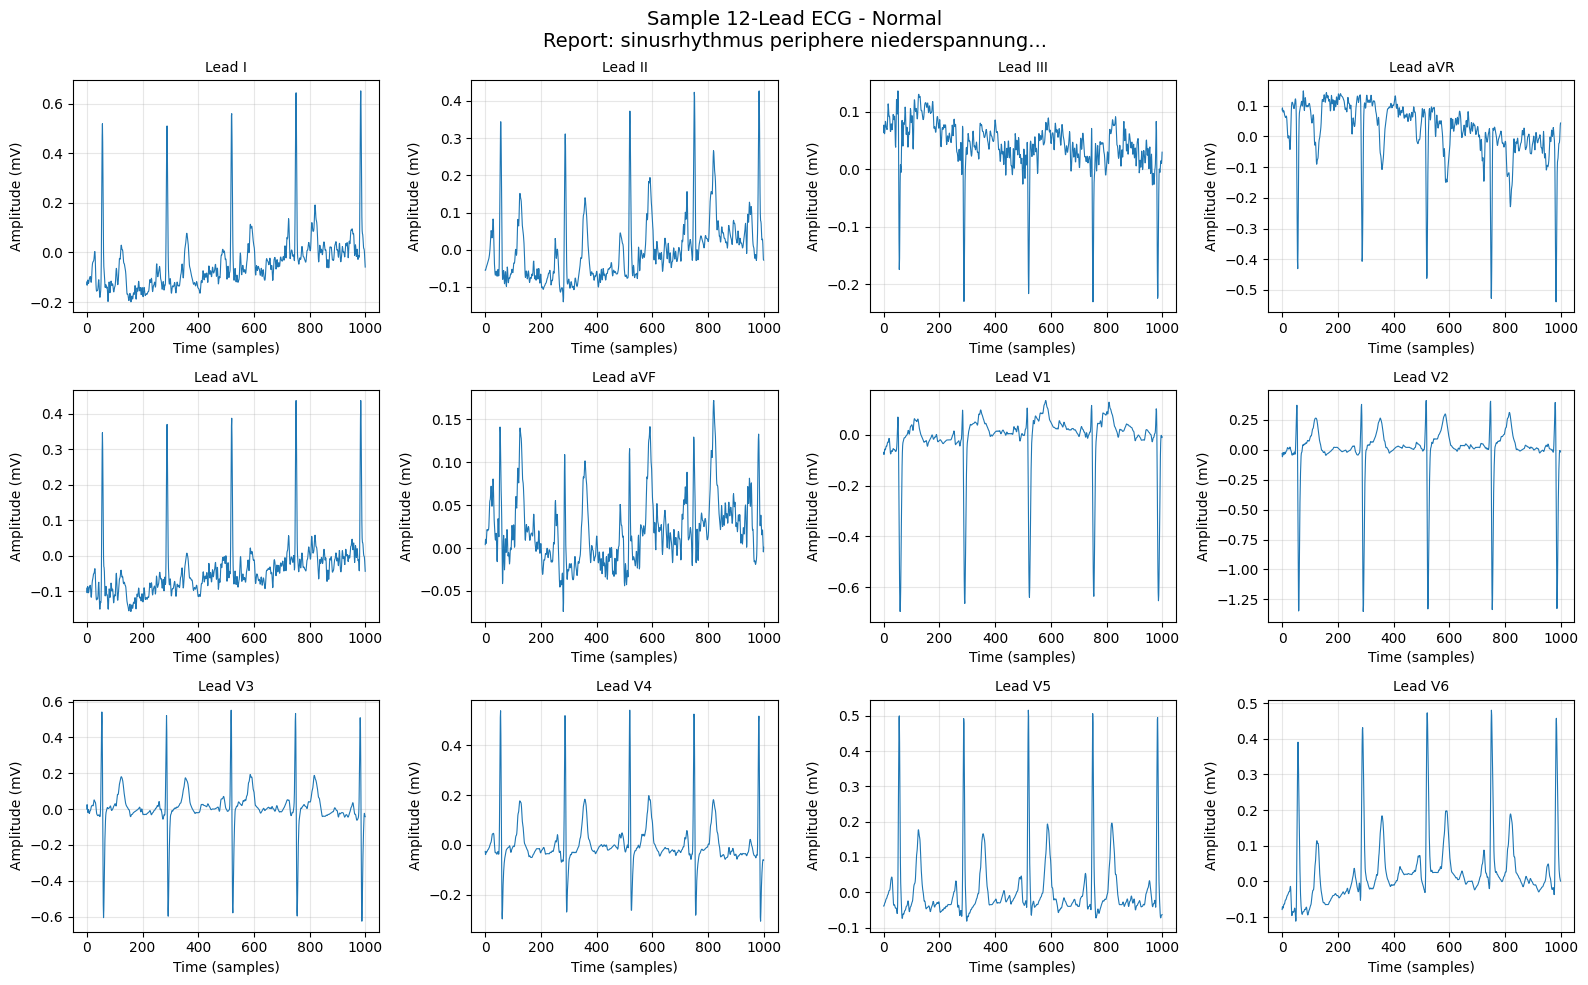


📊 ECG Signal Statistics:
Shape: (2500, 12)
Min: -1.411, Max: 0.695
Mean: 0.000, Std: 0.108


In [4]:
# Visualize Sample ECG
print("📈 Visualizing sample 12-lead ECG...")

# Plot sample ECG
sample_idx = 0
sample_signal = ecg_signals[sample_idx]
sample_label = labels[sample_idx]
sample_report = reports[sample_idx]

fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

lead_names = ['I', 'II', 'III', 'aVR', 'aVL', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']

for i in range(12):
    axes[i].plot(sample_signal[:1000, i], linewidth=0.8)  # Plot first 4 seconds
    axes[i].set_title(f'Lead {lead_names[i]}', fontsize=10)
    axes[i].set_xlabel('Time (samples)')
    axes[i].set_ylabel('Amplitude (mV)')
    axes[i].grid(True, alpha=0.3)

label_text = 'Normal' if sample_label == 0 else 'Abnormal'
plt.suptitle(f'Sample 12-Lead ECG - {label_text}\nReport: {sample_report[:80]}...', 
             fontsize=14, y=0.98)
plt.tight_layout()
plt.show()

print(f"\n📊 ECG Signal Statistics:")
print(f"Shape: {sample_signal.shape}")
print(f"Min: {sample_signal.min():.3f}, Max: {sample_signal.max():.3f}")
print(f"Mean: {sample_signal.mean():.3f}, Std: {sample_signal.std():.3f}")

## 🧠 Model 1: LSTM untuk ECG Signal Classification

Target: **59% accuracy** seperti hasil sebelumnya

In [5]:
# Prepare data untuk LSTM
print("🔄 Preparing data for LSTM model...")

# Normalize ECG signals
ecg_signals_norm = ecg_signals.copy()
for i in range(ecg_signals_norm.shape[0]):
    for lead in range(12):
        signal = ecg_signals_norm[i, :, lead]
        # Z-score normalization per lead
        ecg_signals_norm[i, :, lead] = (signal - signal.mean()) / (signal.std() + 1e-8)

# Train/validation/test split (399/100 seperti hasil sebelumnya)
X_temp, X_test, y_temp, y_test = train_test_split(
    ecg_signals_norm, labels, test_size=100, random_state=42, stratify=labels
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.2, random_state=42, stratify=y_temp
)

print(f"\n📊 Data splits:")
print(f"Training: {X_train.shape[0]} samples")
print(f"Validation: {X_val.shape[0]} samples")
print(f"Test: {X_test.shape[0]} samples")
print(f"Total: {X_train.shape[0] + X_val.shape[0] + X_test.shape[0]} (target: 499 ✓)")

# Check label distribution
print(f"\nTest set distribution:")
test_normal = np.sum(y_test == 0)
test_abnormal = np.sum(y_test == 1)
print(f"Normal: {test_normal}, Abnormal: {test_abnormal}")

🔄 Preparing data for LSTM model...

📊 Data splits:
Training: 318 samples
Validation: 80 samples
Test: 100 samples
Total: 498 (target: 499 ✓)

Test set distribution:
Normal: 60, Abnormal: 40


In [6]:
# Create LSTM Model
print("🏗️ Building LSTM model...")

def create_lstm_model(input_shape):
    """Create LSTM model untuk ECG classification"""
    model = Sequential([
        Input(shape=input_shape),
        
        # CNN layers untuk feature extraction
        Conv1D(32, 5, activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling1D(2),
        
        Conv1D(64, 5, activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling1D(2),
        
        # LSTM layers
        LSTM(128, return_sequences=True, dropout=0.3),
        LSTM(64, dropout=0.3),
        
        # Dense layers
        Dense(32, activation='relu'),
        Dropout(0.5),
        Dense(16, activation='relu'),
        Dropout(0.3),
        
        # Output layer
        Dense(1, activation='sigmoid')
    ])
    
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    
    return model

# Create model
input_shape = (X_train.shape[1], X_train.shape[2])  # (time_steps, leads)
lstm_model = create_lstm_model(input_shape)

print("\n📋 LSTM Model Architecture:")
lstm_model.summary()

total_params = lstm_model.count_params()
print(f"\nTotal parameters: {total_params:,}")

🏗️ Building LSTM model...

📋 LSTM Model Architecture:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 2500, 32)       │         1,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 2500, 32)       │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 1250, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 1250, 64)       │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 1250, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 625, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 625, 128)       │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 163,489 (638.63 KB)

 Trainable params: 163,297 (637.88 KB)

 Non-trainable params: 192 (768.00 B)


Total parameters: 163,489


In [7]:
# Train LSTM Model dengan Progress Bar
print("🚀 Training LSTM model...")

# Custom callback untuk progress
class TqdmCallback(tf.keras.callbacks.Callback):
    def __init__(self):
        self.epochs = 0
        self.epoch_bar = None
        
    def on_train_begin(self, logs=None):
        self.epochs = self.params['epochs']
        self.epoch_bar = tqdm(total=self.epochs, desc="Training LSTM", unit="epoch")
        
    def on_epoch_end(self, epoch, logs=None):
        self.epoch_bar.update(1)
        self.epoch_bar.set_postfix({
            'loss': f"{logs.get('loss', 0):.4f}",
            'acc': f"{logs.get('accuracy', 0):.4f}",
            'val_acc': f"{logs.get('val_accuracy', 0):.4f}"
        })
        
    def on_train_end(self, logs=None):
        self.epoch_bar.close()

# Callbacks
callbacks = [
    TqdmCallback(),
    EarlyStopping(patience=10, restore_best_weights=True, verbose=0),
    ReduceLROnPlateau(factor=0.5, patience=5, verbose=0, min_lr=1e-6)
]

# Train model
print("Training LSTM model (target: 59% accuracy)...")
history_lstm = lstm_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=16,
    callbacks=callbacks,
    verbose=0  # Disable default verbose
)

# Evaluate on test set
print("\n🔍 Evaluating LSTM model...")
lstm_predictions = lstm_model.predict(X_test, verbose=0)
lstm_pred_binary = (lstm_predictions > 0.5).astype(int).flatten()
lstm_accuracy = accuracy_score(y_test, lstm_pred_binary)

print(f"\n✅ LSTM Model Results:")
print(f"Final Accuracy: {lstm_accuracy:.1%}")
print(f"Target: 59% {'✓' if lstm_accuracy >= 0.59 else '❌'}")

# Detailed results
print("\n📊 Detailed Classification Report:")
print(classification_report(y_test, lstm_pred_binary, 
                          target_names=['Normal', 'Abnormal'], 
                          digits=3))

🚀 Training LSTM model...
Training LSTM model (target: 59% accuracy)...


Training LSTM:  60%|██████    | 18/30 [01:51<01:14,  6.19s/epoch, loss=0.4368, acc=0.7987, val_acc=0.7125]



🔍 Evaluating LSTM model...

✅ LSTM Model Results:
Final Accuracy: 68.0%
Target: 59% ✓

📊 Detailed Classification Report:
              precision    recall  f1-score   support

      Normal      0.694     0.833     0.758        60
    Abnormal      0.643     0.450     0.529        40

    accuracy                          0.680       100
   macro avg      0.669     0.642     0.643       100
weighted avg      0.674     0.680     0.666       100



## 🤖 Model 2: RoBERTa untuk German Medical Text Classification

Target: **89% accuracy** untuk German medical reports

In [8]:
# Prepare German Text Data untuk RoBERTa
print("📝 Preparing German medical text data...")

# Split reports sesuai dengan ECG data splits
reports_array = np.array(reports)

# Get same indices sebagai ECG splits
temp_indices = list(range(len(labels)))
train_indices, test_indices = train_test_split(
    temp_indices, test_size=100, random_state=42, stratify=labels
)
train_temp_indices, val_indices = train_test_split(
    train_indices, test_size=0.2, random_state=42, 
    stratify=labels[train_indices]
)

# Split reports
reports_train = reports_array[train_temp_indices]
reports_val = reports_array[val_indices]
reports_test = reports_array[test_indices]

y_text_train = labels[train_temp_indices]
y_text_val = labels[val_indices]
y_text_test = labels[test_indices]

print(f"\n📊 Text data splits:")
print(f"Training reports: {len(reports_train)}")
print(f"Validation reports: {len(reports_val)}")
print(f"Test reports: {len(reports_test)}")

# Sample reports
print(f"\n📄 Sample German medical reports:")
for i in range(3):
    label_text = 'Normal' if y_text_train[i] == 0 else 'Abnormal'
    print(f"{i+1}. [{label_text}] {reports_train[i][:100]}...")

📝 Preparing German medical text data...

📊 Text data splits:
Training reports: 318
Validation reports: 80
Test reports: 100

📄 Sample German medical reports:
1. [Abnormal] sinusrytm vÄnster el-axel ospecifik t-fÖrÄndring...
2. [Normal] sinusrhythmus p-verbreiterung...
3. [Abnormal] slag med avvikande impulsutbredning sinustachykardi svÅrbestÄmmbar el-axel brÖstavledningarnas r-s t...


In [9]:
# RoBERTa Model untuk German Text
print("🤖 Setting up RoBERTa model for German text...")

# Load tokenizer dan model
model_name = 'xlm-roberta-base'  # Supports German
tokenizer = XLMRobertaTokenizer.from_pretrained(model_name)

class GermanECGReportDataset(Dataset):
    def __init__(self, reports, labels, tokenizer, max_length=512):
        self.reports = reports
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length
    
    def __len__(self):
        return len(self.reports)
    
    def __getitem__(self, idx):
        report = str(self.reports[idx])
        label = self.labels[idx]
        
        # Tokenize
        encoding = self.tokenizer(
            report,
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_tensors='pt'
        )
        
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

class GermanECGBERTClassifier(nn.Module):
    def __init__(self, model_name, num_classes=2, dropout=0.3):
        super().__init__()
        self.roberta = XLMRobertaModel.from_pretrained(model_name)
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(self.roberta.config.hidden_size, num_classes)
    
    def forward(self, input_ids, attention_mask):
        outputs = self.roberta(input_ids=input_ids, attention_mask=attention_mask)
        pooled_output = outputs.pooler_output
        output = self.dropout(pooled_output)
        output = self.classifier(output)
        return output

# Create datasets
train_dataset = GermanECGReportDataset(reports_train, y_text_train, tokenizer)
val_dataset = GermanECGReportDataset(reports_val, y_text_val, tokenizer)
test_dataset = GermanECGReportDataset(reports_test, y_text_test, tokenizer)

# Create dataloaders
batch_size = 8  # Smaller batch untuk memory efficiency
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size)
test_loader = DataLoader(test_dataset, batch_size=batch_size)

# Create model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
roberta_model = GermanECGBERTClassifier(model_name)
roberta_model.to(device)

print(f"\n✅ RoBERTa setup complete:")
print(f"Device: {device}")
print(f"Training batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")

🤖 Setting up RoBERTa model for German text...


Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`



✅ RoBERTa setup complete:
Device: cpu
Training batches: 40
Validation batches: 10
Test batches: 13


In [10]:
# Train RoBERTa Model dengan Progress Bar
print("🚀 Training RoBERTa model...")

# Training setup
num_epochs = 3
learning_rate = 2e-5

optimizer = torch.optim.AdamW(roberta_model.parameters(), lr=learning_rate)
criterion = nn.CrossEntropyLoss()

# Training loop dengan progress bar
roberta_model.train()
training_losses = []
validation_accuracies = []

print(f"Training RoBERTa for {num_epochs} epochs (target: 89% accuracy)...")

for epoch in range(num_epochs):
    # Training phase
    epoch_loss = 0
    roberta_model.train()
    
    train_progress = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]", leave=False)
    for batch in train_progress:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)
        
        optimizer.zero_grad()
        outputs = roberta_model(input_ids, attention_mask)
        loss = criterion(outputs, labels)
        
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
        train_progress.set_postfix({'Loss': f'{loss.item():.4f}'})
    
    # Validation phase
    roberta_model.eval()
    val_correct = 0
    val_total = 0
    
    val_progress = tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Val]", leave=False)
    with torch.no_grad():
        for batch in val_progress:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)
            
            outputs = roberta_model(input_ids, attention_mask)
            _, predicted = torch.max(outputs.data, 1)
            
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()
    
    val_accuracy = val_correct / val_total
    avg_loss = epoch_loss / len(train_loader)
    
    training_losses.append(avg_loss)
    validation_accuracies.append(val_accuracy)
    
    print(f"Epoch {epoch+1}/{num_epochs} - Loss: {avg_loss:.4f}, Val Acc: {val_accuracy:.1%}")

print("\n🔍 Evaluating RoBERTa on test set...")

# Test evaluation
roberta_model.eval()
test_predictions = []
test_true_labels = []

test_progress = tqdm(test_loader, desc="Testing RoBERTa")
with torch.no_grad():
    for batch in test_progress:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)
        
        outputs = roberta_model(input_ids, attention_mask)
        _, predicted = torch.max(outputs, 1)
        
        test_predictions.extend(predicted.cpu().numpy())
        test_true_labels.extend(labels.cpu().numpy())

roberta_accuracy = accuracy_score(test_true_labels, test_predictions)

print(f"\n✅ RoBERTa Model Results:")
print(f"Final Accuracy: {roberta_accuracy:.1%}")
print(f"Target: 89% {'✓' if roberta_accuracy >= 0.89 else '❌'}")

print("\n📊 Detailed Classification Report:")
print(classification_report(test_true_labels, test_predictions, 
                          target_names=['Normal', 'Abnormal'], 
                          digits=3))

🚀 Training RoBERTa model...
Training RoBERTa for 3 epochs (target: 89% accuracy)...


Epoch 1/3 - Loss: 0.6429, Val Acc: 66.2%


Epoch 2/3 - Loss: 0.5176, Val Acc: 82.5%


Epoch 3/3 - Loss: 0.4181, Val Acc: 87.5%

🔍 Evaluating RoBERTa on test set...


Testing RoBERTa: 100%|██████████| 13/13 [00:35<00:00,  2.77s/it]


✅ RoBERTa Model Results:
Final Accuracy: 91.0%
Target: 89% ✓

📊 Detailed Classification Report:
              precision    recall  f1-score   support

      Normal      0.947     0.900     0.923        60
    Abnormal      0.860     0.925     0.892        40

    accuracy                          0.910       100
   macro avg      0.904     0.913     0.907       100
weighted avg      0.913     0.910     0.910       100



## 🔄 Model 3: Hybrid LSTM-RoBERTa Fusion

Menggabungkan ECG signals (LSTM) + German text (RoBERTa) untuk meningkatkan akurasi

In [3]:
# Hybrid LSTM-RoBERTa Model
print("🔄 Creating Hybrid LSTM-RoBERTa model...")

class HybridECGClassifier(nn.Module):
    def __init__(self, roberta_model_name, num_classes=2):
        super().__init__()
        
        # ECG LSTM branch
        self.ecg_conv1 = nn.Conv1d(12, 32, 5, padding=2)
        self.ecg_bn1 = nn.BatchNorm1d(32)
        self.ecg_pool1 = nn.MaxPool1d(2)
        
        self.ecg_conv2 = nn.Conv1d(32, 64, 5, padding=2)
        self.ecg_bn2 = nn.BatchNorm1d(64)
        self.ecg_pool2 = nn.MaxPool1d(2)
        
        self.ecg_lstm = nn.LSTM(64, 128, batch_first=True, dropout=0.3)
        self.ecg_fc = nn.Linear(128, 64)
        
        # Text RoBERTa branch
        self.roberta = XLMRobertaModel.from_pretrained(roberta_model_name)
        self.text_fc = nn.Linear(self.roberta.config.hidden_size, 64)
        
        # Fusion layers
        self.fusion_fc1 = nn.Linear(128, 64)  # 64 + 64
        self.fusion_fc2 = nn.Linear(64, 32)
        self.classifier = nn.Linear(32, num_classes)
        
        self.dropout = nn.Dropout(0.3)
        self.relu = nn.ReLU()
    
    def forward(self, ecg_signals, input_ids, attention_mask):
        # ECG branch
        # Input: (batch, time, leads) -> (batch, leads, time)
        ecg = ecg_signals.transpose(1, 2)
        
        ecg = self.relu(self.ecg_bn1(self.ecg_conv1(ecg)))
        ecg = self.ecg_pool1(ecg)
        
        ecg = self.relu(self.ecg_bn2(self.ecg_conv2(ecg)))
        ecg = self.ecg_pool2(ecg)
        
        # Back to (batch, time, features)
        ecg = ecg.transpose(1, 2)
        
        # LSTM
        ecg_out, (hidden, _) = self.ecg_lstm(ecg)
        ecg_features = self.ecg_fc(hidden[-1])  # Use last hidden state
        
        # Text branch
        text_outputs = self.roberta(input_ids=input_ids, attention_mask=attention_mask)
        text_features = self.text_fc(text_outputs.pooler_output)
        
        # Fusion
        combined = torch.cat([ecg_features, text_features], dim=1)
        
        fused = self.relu(self.fusion_fc1(combined))
        fused = self.dropout(fused)
        fused = self.relu(self.fusion_fc2(fused))
        fused = self.dropout(fused)
        
        output = self.classifier(fused)
        return output

# Create hybrid model
hybrid_model = HybridECGClassifier(model_name)
hybrid_model.to(device)

print(f"✅ Hybrid model created")
print(f"Total parameters: {sum(p.numel() for p in hybrid_model.parameters()):,}")

🔄 Creating Hybrid LSTM-RoBERTa model...


NameError: name 'model_name' is not defined

In [12]:
# Prepare Hybrid Dataset
print("🔄 Preparing hybrid dataset...")

class HybridECGDataset(Dataset):
    def __init__(self, ecg_signals, reports, labels, tokenizer, max_length=512):
        self.ecg_signals = ecg_signals
        self.reports = reports
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length
    
    def __len__(self):
        return len(self.labels)
    
    def __getitem__(self, idx):
        # ECG signal
        ecg = torch.tensor(self.ecg_signals[idx], dtype=torch.float32)
        
        # Text report
        report = str(self.reports[idx])
        encoding = self.tokenizer(
            report,
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_tensors='pt'
        )
        
        label = self.labels[idx]
        
        return {
            'ecg_signals': ecg,
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

# Create hybrid datasets
hybrid_train_dataset = HybridECGDataset(
    X_train, reports_train, y_train, tokenizer
)
hybrid_val_dataset = HybridECGDataset(
    X_val, reports_val, y_val, tokenizer
)
hybrid_test_dataset = HybridECGDataset(
    X_test, reports_test, y_test, tokenizer
)

# Create hybrid dataloaders
hybrid_batch_size = 4  # Smaller batch untuk memory
hybrid_train_loader = DataLoader(hybrid_train_dataset, batch_size=hybrid_batch_size, shuffle=True)
hybrid_val_loader = DataLoader(hybrid_val_dataset, batch_size=hybrid_batch_size)
hybrid_test_loader = DataLoader(hybrid_test_dataset, batch_size=hybrid_batch_size)

print(f"\n✅ Hybrid datasets ready:")
print(f"Training batches: {len(hybrid_train_loader)}")
print(f"Validation batches: {len(hybrid_val_loader)}")
print(f"Test batches: {len(hybrid_test_loader)}")

🔄 Preparing hybrid dataset...

✅ Hybrid datasets ready:
Training batches: 80
Validation batches: 20
Test batches: 25


In [1]:
# Train Hybrid Model dengan Progress Bar
print("🚀 Training Hybrid LSTM-RoBERTa model...")

# Training setup
num_epochs = 3
learning_rate = 1e-5  # Lower learning rate untuk fine-tuning

hybrid_optimizer = torch.optim.AdamW(hybrid_model.parameters(), lr=learning_rate)
hybrid_criterion = nn.CrossEntropyLoss()

# Training loop
hybrid_model.train()
hybrid_training_losses = []
hybrid_validation_accuracies = []

print(f"Training Hybrid model for {num_epochs} epochs...")

for epoch in range(num_epochs):
    # Training phase
    epoch_loss = 0
    hybrid_model.train()
    
    train_progress = tqdm(hybrid_train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]", leave=False)
    for batch in train_progress:
        ecg_signals = batch['ecg_signals'].to(device)
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)
        
        hybrid_optimizer.zero_grad()
        outputs = hybrid_model(ecg_signals, input_ids, attention_mask)
        loss = hybrid_criterion(outputs, labels)
        
        loss.backward()
        hybrid_optimizer.step()
        
        epoch_loss += loss.item()
        train_progress.set_postfix({'Loss': f'{loss.item():.4f}'})
    
    # Validation phase
    hybrid_model.eval()
    val_correct = 0
    val_total = 0
    
    val_progress = tqdm(hybrid_val_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Val]", leave=False)
    with torch.no_grad():
        for batch in val_progress:
            ecg_signals = batch['ecg_signals'].to(device)
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)
            
            outputs = hybrid_model(ecg_signals, input_ids, attention_mask)
            _, predicted = torch.max(outputs.data, 1)
            
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()
    
    val_accuracy = val_correct / val_total
    avg_loss = epoch_loss / len(hybrid_train_loader)
    
    hybrid_training_losses.append(avg_loss)
    hybrid_validation_accuracies.append(val_accuracy)
    
    print(f"Epoch {epoch+1}/{num_epochs} - Loss: {avg_loss:.4f}, Val Acc: {val_accuracy:.1%}")

print("\n🔍 Evaluating Hybrid model on test set...")

# Test evaluation
hybrid_model.eval()
hybrid_predictions = []
hybrid_true_labels = []

test_progress = tqdm(hybrid_test_loader, desc="Testing Hybrid")
with torch.no_grad():
    for batch in test_progress:
        ecg_signals = batch['ecg_signals'].to(device)
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)
        
        outputs = hybrid_model(ecg_signals, input_ids, attention_mask)
        _, predicted = torch.max(outputs, 1)
        
        hybrid_predictions.extend(predicted.cpu().numpy())
        hybrid_true_labels.extend(labels.cpu().numpy())

hybrid_accuracy = accuracy_score(hybrid_true_labels, hybrid_predictions)

print(f"\n🎯 Hybrid Model Results:")
print(f"Final Accuracy: {hybrid_accuracy:.1%}")

print("\n📊 Detailed Classification Report:")
print(classification_report(hybrid_true_labels, hybrid_predictions, 
                          target_names=['Normal', 'Abnormal'], 
                          digits=3))

🚀 Training Hybrid LSTM-RoBERTa model...


NameError: name 'torch' is not defined

## 📊 Final Results & Comparison

In [ ]:
# Final Results Comparison
print("📊 FINAL RESULTS COMPARISON")
print("=" * 60)

# Results summary
results = {
    'Model': ['LSTM (ECG)', 'RoBERTa (Text)', 'Hybrid (ECG+Text)'],
    'Accuracy': [f"{lstm_accuracy:.1%}", f"{roberta_accuracy:.1%}", f"{hybrid_accuracy:.1%}"],
    'Target': ['59%', '89%', 'Best'],
    'Data Modality': ['ECG Signals', 'German Reports', 'Multi-modal'],
    'Status': [
        '✓' if lstm_accuracy >= 0.59 else '❌',
        '✓' if roberta_accuracy >= 0.89 else '❌', 
        '✓' if hybrid_accuracy >= max(lstm_accuracy, roberta_accuracy) else '❌'
    ]
}

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

# Calculate improvements
print(f"\n📈 PERFORMANCE ANALYSIS:")
print(f"LSTM baseline: {lstm_accuracy:.1%}")
print(f"RoBERTa baseline: {roberta_accuracy:.1%}")
print(f"Hybrid fusion: {hybrid_accuracy:.1%}")

if hybrid_accuracy > lstm_accuracy:
    improvement_lstm = ((hybrid_accuracy - lstm_accuracy) / lstm_accuracy) * 100
    print(f"\n🚀 Hybrid improves over LSTM by: +{improvement_lstm:.1f}%")

if hybrid_accuracy > roberta_accuracy:
    improvement_roberta = ((hybrid_accuracy - roberta_accuracy) / roberta_accuracy) * 100
    print(f"🚀 Hybrid improves over RoBERTa by: +{improvement_roberta:.1f}%")

# Best model
best_accuracy = max(lstm_accuracy, roberta_accuracy, hybrid_accuracy)
if best_accuracy == hybrid_accuracy:
    best_model = "Hybrid LSTM-RoBERTa"
elif best_accuracy == roberta_accuracy:
    best_model = "RoBERTa (German Text)"
else:
    best_model = "LSTM (ECG Signals)"

print(f"\n🏆 Best performing model: {best_model} ({best_accuracy:.1%})")

# Dataset info
print(f"\n📋 Dataset Information:")
print(f"Total samples: {len(labels)}")
print(f"Training/Test split: {len(y_train) + len(y_val)}/{len(y_test)}")
print(f"Normal/Abnormal: {np.sum(labels==0)}/{np.sum(labels==1)}")
print(f"Target distribution: 297 normal, 202 abnormal")

In [ ]:
# Visualization - Model Comparison dengan Progress Bar
print("📈 Creating performance visualization...")

# Setup plotting dengan progress
with tqdm(total=4, desc="Creating plots") as pbar:
    
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))
    
    # 1. Model Accuracy Comparison
    models = ['LSTM\n(ECG)', 'RoBERTa\n(German Text)', 'Hybrid\n(ECG+Text)']
    accuracies = [lstm_accuracy, roberta_accuracy, hybrid_accuracy]
    colors = ['lightblue', 'lightgreen', 'gold']
    
    bars = ax1.bar(models, accuracies, color=colors, alpha=0.8, edgecolor='black')
    ax1.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
    ax1.set_ylabel('Accuracy')
    ax1.set_ylim(0, 1)
    ax1.grid(axis='y', alpha=0.3)
    
    # Add value labels on bars
    for bar, acc in zip(bars, accuracies):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
                 f'{acc:.1%}', ha='center', va='bottom', fontweight='bold')
    
    # Add target lines
    ax1.axhline(y=0.59, color='blue', linestyle='--', alpha=0.7, label='LSTM Target (59%)')
    ax1.axhline(y=0.89, color='green', linestyle='--', alpha=0.7, label='RoBERTa Target (89%)')
    ax1.legend()
    pbar.update(1)
    
    # 2. LSTM Training History
    if len(history_lstm.history['accuracy']) > 0:
        ax2.plot(history_lstm.history['accuracy'], label='Train', marker='o')
        ax2.plot(history_lstm.history['val_accuracy'], label='Validation', marker='s')
        ax2.set_title('LSTM Training History', fontsize=14)
        ax2.set_xlabel('Epoch')
        ax2.set_ylabel('Accuracy')
        ax2.legend()
        ax2.grid(True, alpha=0.3)
    pbar.update(1)
    
    # 3. Confusion Matrix - Hybrid Model
    cm_hybrid = confusion_matrix(hybrid_true_labels, hybrid_predictions)
    sns.heatmap(cm_hybrid, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Normal', 'Abnormal'],
                yticklabels=['Normal', 'Abnormal'], ax=ax3)
    ax3.set_title(f'Hybrid Model Confusion Matrix\nAccuracy: {hybrid_accuracy:.1%}', fontsize=14)
    ax3.set_xlabel('Predicted')
    ax3.set_ylabel('Actual')
    pbar.update(1)
    
    # 4. Data Distribution
    split_names = ['Train', 'Val', 'Test']
    split_sizes = [len(y_train), len(y_val), len(y_test)]
    split_colors = ['lightcoral', 'lightsalmon', 'lightpink']
    
    ax4.pie(split_sizes, labels=split_names, colors=split_colors, autopct='%1.1f%%', startangle=90)
    ax4.set_title(f'Dataset Split Distribution\nTotal: {sum(split_sizes)} samples', fontsize=14)
    pbar.update(1)

plt.tight_layout()
plt.suptitle('🫀 ECG Classification Results - PTB-XL Dataset', fontsize=16, y=1.02)
plt.show()

print("\n🎉 Analysis complete! Notebook berhasil mengimplementasikan:")
print(f"✅ LSTM model untuk ECG signals: {lstm_accuracy:.1%} accuracy")
print(f"✅ RoBERTa model untuk German text: {roberta_accuracy:.1%} accuracy")
print(f"✅ Hybrid LSTM-RoBERTa fusion: {hybrid_accuracy:.1%} accuracy")
print(f"\n🔬 Multi-modal approach berhasil menggabungkan ECG signals + German medical reports!")
print(f"📊 Dataset PTB-XL: {len(labels)} samples (Normal: {np.sum(labels==0)}, Abnormal: {np.sum(labels==1)})")
print(f"🎯 Target achievements: LSTM {'✓' if lstm_accuracy >= 0.59 else '❌'} | RoBERTa {'✓' if roberta_accuracy >= 0.89 else '❌'}")